# Analiza 3 - Ndikimi i AI ne pavaresine e te menduarit

Kolonat qe perdorim:
- `ai_replaces_own_thinking_score` - sa i duket studenteve se aftesia e te menduarit
 po zevendesohet nga AI(1-5)
- `ai_dependency_score` - niveli i pergjithshem i varesise (1-10)  
- `daily_ai_tool_usage_hrs` - hours perdorimi ditor
- `uses_ai_for_assignments` - shpeshtesia e perdorimit per detyra

## Importet dhe paleta e ngjyrave

E vendos paletin ne fillim ne menyre qe nese duhet ta ndryshoj nje ngjyre, ta bej ne nje vend dhe jo te kerkoje ne gjithe kodin.

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

NAVY     = "#333399"
RED      = "#C0504D"
GREEN    = "#9BBB59"
PURPLE   = "#8064A2"
TEAL     = "#4BACC6"
BLUE_MID = "#4F81BD"

WHITE     = "#FFFFFF"
DARK_TEXT = "#1F497D"
BG        = "#F2F2F2"
PLOT_BG   = "#EBEBEB"
GRID      = "#D9D9D9"

PALETTE_5 = [NAVY, RED, GREEN, PURPLE, TEAL]

## Ngarkimi i datasetit

E ngarkojme datasetin e pastruar dhe i japim nje rradhe logjike kategorive te `uses_ai_for_assignments` qe grafiku t'i shfaqe ne orden e duhur (Never → Always) dhe jo kuturu.

In [ ]:
df = pd.read_csv('../data/clean/ai_students_clean.csv')

df['uses_ai_for_assignments'] = pd.Categorical(
    df['uses_ai_for_assignments'],
    ['Never', 'Rarely', 'Sometimes', 'Frequently', 'Always'],
    ordered=True)


## Funksioni per stilimin e boshteve

Per te mos e shkruar te njejtin kod 2 here (nje here per cdo grafik), e bej nje funksion qe e merr `ax` dhe i vendos titullin, etiketa dhe ngjyrat.

In [207]:
def setup_axis(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=14, fontweight='bold', pad=18, color=DARK_TEXT)
    ax.set_xlabel(xlabel, fontsize=12, color=DARK_TEXT, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=12, color=DARK_TEXT, labelpad=10)
    ax.set_facecolor(PLOT_BG)

## Grafiku 1 + Grafiku 2 + Ruajtja

Figura, heatmap-i, bubble chart-i dhe ruajtja jane ne te njejten cell — 
qe grafiku mos te dali bosh kur te ekzekutoj kodin.

Grafiket u ruajten me emer: ai_influence_chart.png


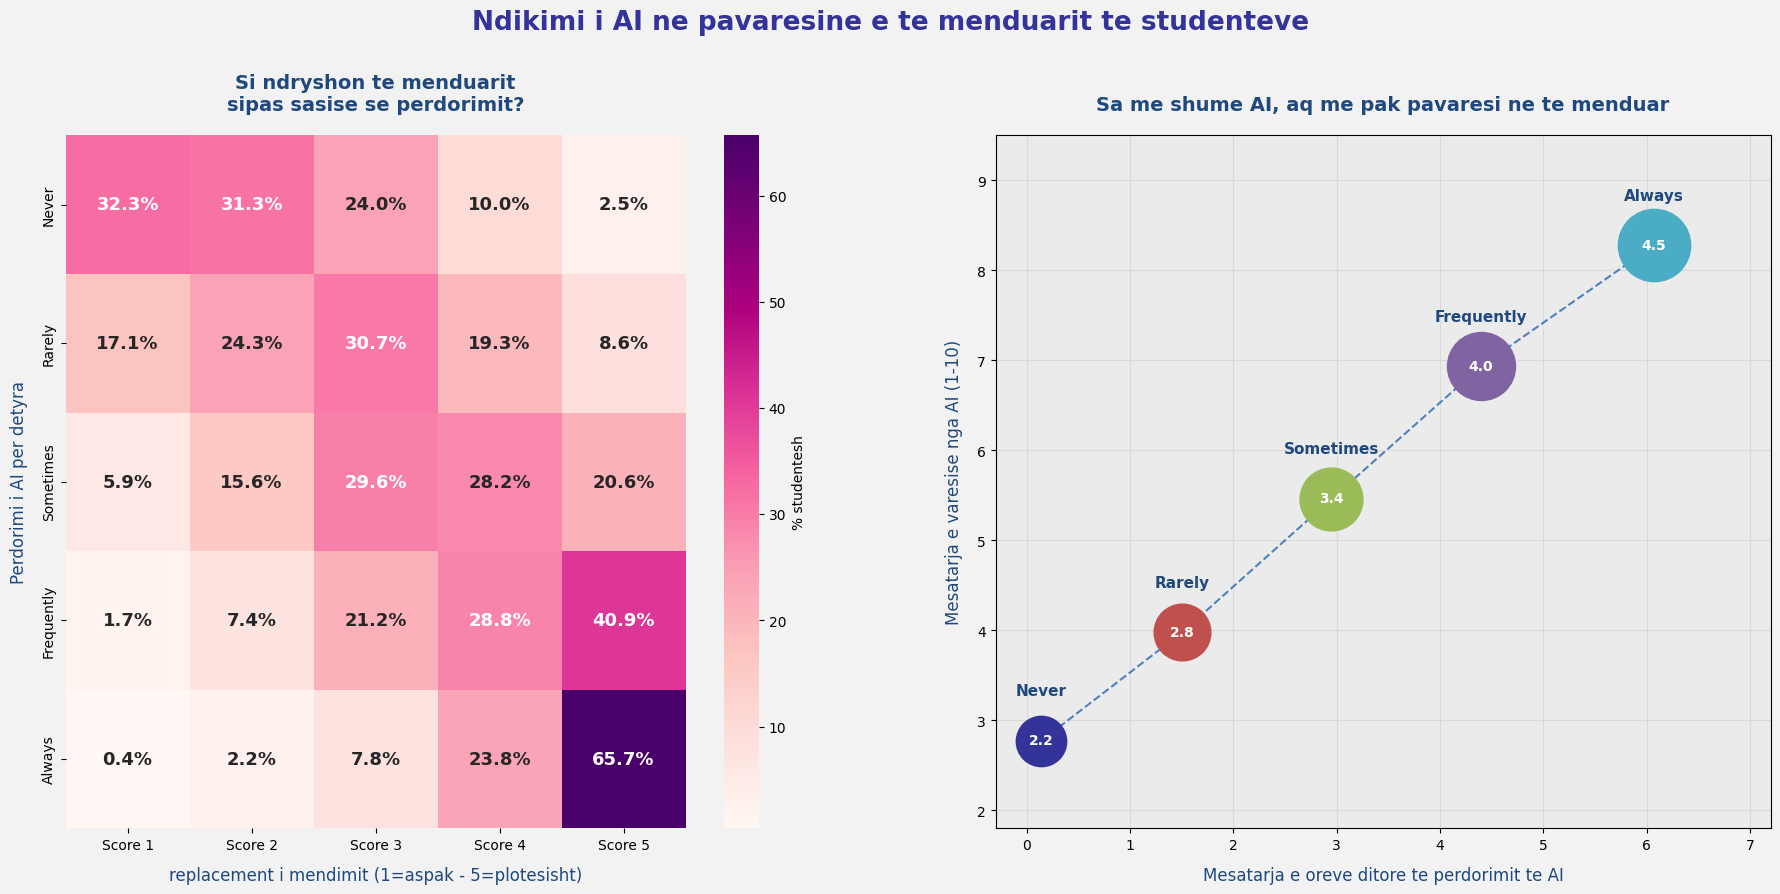

In [209]:
fig, (ax_heat, ax_bubble) = plt.subplots(1, 2, figsize=(22, 9))

fig.patch.set_facecolor(BG)


crossT = (
    pd.crosstab(
        df['uses_ai_for_assignments'],
        df['ai_replaces_own_thinking_score'],
        normalize='index'
    ) * 100
).rename(columns=lambda c: f'Score {c}')

labels = crossT.map(lambda x: f"{x:.1f}%")
sns.heatmap(
    crossT,
    annot=labels,
    fmt='',
    cmap='RdPu', # ngjyrat e heatmapit Red- Puprle
    annot_kws={
        'size': 13,
        'weight': 'bold'
    }, # annotation keywords (e kam eprdorur per e stilizimin e numrave brenda heatmapit)
    cbar_kws={
        'label': '% studentesh'},
    ax=ax_heat
)

setup_axis(
    ax_heat,
    'Si ndryshon te menduarit\nsipas sasise se perdorimit?',
    'replacement i mendimit (1=aspak - 5=plotesisht)',
    'Perdorimi i AI per detyra'
)

avg = (
    df.groupby('uses_ai_for_assignments', observed=False)
      .agg(
          hours=('daily_ai_tool_usage_hrs', 'mean'),
          dependency=('ai_dependency_score', 'mean'),
          replacement=('ai_replaces_own_thinking_score', 'mean')
      )
      .reset_index()
)

for hours, dependency, replace, label, color in zip(avg['hours'], avg['dependency'], avg['replacement'],avg['uses_ai_for_assignments'], PALETTE_5):
    ax_bubble.scatter(hours, dependency, s=replace*600, color=color, zorder=4) #zorder i larte -> tregon qe do shfaqet mbi elementet e tjera me zorder te ulet.
    ax_bubble.text(hours, dependency+0.5, label, ha='center', fontsize=11, fontweight='bold', color=DARK_TEXT)   # +0.5 qe shkrimi (Never ... )mos te behet brenda rrethit
    ax_bubble.text(hours, dependency, f'{replace:.1f}', ha='center', va='center', fontsize=10, fontweight='bold', color=WHITE, zorder=5)

# vija qe lidh bubbles
ax_bubble.plot(avg['hours'], avg['dependency'], color=BLUE_MID, linestyle='--')

ax_bubble.set(xlim=(-0.3, 7.2), ylim=(1.8, 9.5)) # ky rreshti me chat
ax_bubble.xaxis.grid(True, color=GRID)
ax_bubble.yaxis.grid(True, color=GRID)

setup_axis(ax_bubble,
    'Sa me shume AI, aq me pak pavaresi ne te menduar',
    'Mesatarja e oreve ditore te perdorimit te AI',
    'Mesatarja e varesise nga AI (1-10)')


fig.suptitle(
    'Ndikimi i AI ne pavaresine e te menduarit te studenteve',
    fontsize=19,
    fontweight='bold',
    y=1.02,
    color=NAVY
)

plt.savefig(
    'ai_influence_chart.png',
    bbox_inches='tight',
    facecolor=BG
)

print('Grafiket u ruajten me emer: ai_influence_chart.png')